<p style="text-align:right;">Mario Stanke, University of Greifswald, Germany</p>

# Solution to Exercise Set 2 - 2 - Different Activation Functions in a Regression Neural Network

This is a copy of notebook ```nn-regr.ipynb``` for solving the following exercises:

  0. Run all cells.  
   
  1. Replace the sigmoid activation function with the **ReLU** function and observe how the shape of the predicted curve changes. *Revert back* afterwards to the *sigmoid* activation function.
   
  2. **Shift** the simulated data on the **x**-axis by **+50**.  
    2.1. **For the mathematically inclined:**   
    Let $x' := x + 50$. Show or argue that it theoretically does not matter if you shift (use input $x'$) or not (use $x$):  *For any neural net $f(x)$ there is a neural net $f'(x')$ such that $f'(x') = f(x)$*. You may assume that $n=1$.  
    2.2. **Go to ADD YOUR CODE HERE** and follow the instructions. Run all cells. What happens to the goodness of the fit? Do you have an explanation? Tip: Compute the net activations of the first layer manually right before training starts.

### **Answer to 2.1.:**
<img style="float:left" src="../../reparametrize.png" width="200px" />

Let $z_j$ be any particular net activation of the first hidden layer. We omit the superscripts that indicate the layers, here.

$$\begin{align*}
z_j &= \theta_{j,0} + \theta_{j,1} \cdot x\\
&=  \theta_{j,0} + \theta_{j,1} \cdot (x' - 50)\\
&= (\theta_{j,0} - 50 \cdot \theta_{j,1}) + \theta_{j,1} \cdot x'\\
&= \theta'_{j,0} + \theta_{j,1} \cdot x'
\end{align*}
$$

if one defines the bias term for the $j$-th unit of the first hidden layer of $f'$ as $\theta'_{j,0}:=\theta_{j,0} - 50 \cdot \theta_{j,1}$. Therefore, the activations of the first hidden layer are equal in the two networks and the remaining layers can be identical for the two networks to compute identical functions.

## Generate an Artificial Dataset

In [1]:
# import libraries
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input

2025-03-09 09:42:23.363061: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-09 09:42:23.363396: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-09 09:42:23.366712: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-09 09:42:23.399818: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-09 09:42:24.068221: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warnin

In [2]:
def f(x):
    '''A simple one-dimensional function with a few extrema'''
    return np.sin(15 * x) + 9 * x - 9 * x**2

#### Simulate $(x, y)$ pairs as artificial data set

In [3]:
np.random.seed(1)
m = 100 # number of data points (examples)
x = np.linspace(0, 1, m) # equidistant in [0,1] (both boundaries included)
y_theoretical = f(x)     # the points on the curve
# ADD YOUR CODE HERE to shift x by +50, 1 line
x = x + 50
# YOUR CODE ENDS
sigma = 0.1
y = y_theoretical + sigma * np.random.randn(m) # observations have noise (normal with mean 0 and variance sigma^2 = 0.01)

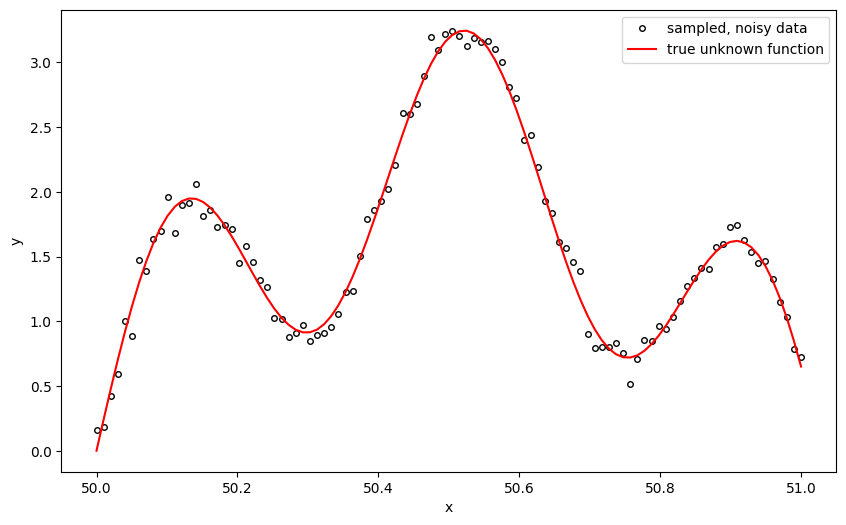

In [4]:
def plot_curve():
    fig, ax = plt.subplots(figsize = (10, 6))
    ax.plot(x, y, 'ko', fillstyle = 'none', markersize = 4, label = "sampled, noisy data") # ko: blac(k) circle
    ax.plot(x, y_theoretical, 'r', label = "true unknown function")
    plt.xlabel("x")
    plt.ylabel("y")
    return ax

ax = plot_curve()
ax.legend();

## Create Neural Network Model  
We will use [```tf.keras```](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/keras), a high-level approach to neural network design and learning. The NN shall have 2 hidden layers with 8 neurons each. As activation functions we chose the logistic sigmoid function $\sigma$.

<img src="../../nn8-8.png" alt="network architecture" width="500"/>

In [5]:
tf.random.set_seed(13032021) # so we all get the same pseudorandom results

# a neural network is a stack of layers, in keras called "Sequential" model
model = tf.keras.models.Sequential() # so far the stack is empty, 0 layers
model.add(Input(shape=(1,))) # implicitly specifies the input dimension

# add neural network layers one by one
# Dense is a fully connected layer, parametrized by a matrix of shape (input_units, output_units).
# The first number given in Dense is the number of output units, the number of input units is implicit.
# By default use_bias=True which adds output_units parameters for each layer
# REPLACE THE ACTIVATION FUNCTION HERE with tf.nn.relu
model.add(Dense(8, activation = tf.nn.sigmoid, input_dim = 1)) # input dimension only required for first layer
model.add(Dense(8, activation = tf.nn.sigmoid))
# YOUR CHANGES END HERE
model.add(Dense(1))

model.summary()     # summarizes layers and parameters
Theta = model.get_weights() # a look under the 'hood' for teaching purposes
print(Theta)

/home/mario/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-03-09 09:42:24.911373: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-09 09:42:24.911678: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the requir

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97 (388.00 B)

 Trainable params: 97 (388.00 B)

 Non-trainable params: 0 (0.00 B)

[array([[ 0.23129845,  0.7462201 ,  0.7190856 , -0.69868493, -0.29520833,
         0.63048315,  0.26449478,  0.51568925]], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[ 0.10537797, -0.49239528, -0.19224998,  0.06752747, -0.41857412,
        -0.22686157, -0.05708915, -0.00211382],
       [-0.56530786,  0.09838611, -0.13909468,  0.5858565 , -0.01370496,
        -0.43941358,  0.39655036, -0.43489748],
       [-0.18000314, -0.5310327 ,  0.08358777,  0.37021363,  0.35198516,
        -0.17651474,  0.38718522, -0.07512248],
       [-0.3436679 , -0.19724628,  0.44777197, -0.13054794,  0.15840387,
        -0.57811594,  0.50814253, -0.19067276],
       [ 0.2675926 ,  0.13767874, -0.02613956, -0.5230986 ,  0.2033658 ,
        -0.580904  , -0.19151983, -0.0563764 ],
       [-0.07401109,  0.3574692 ,  0.15921187,  0.359873  , -0.48612615,
        -0.05164188, -0.4856969 ,  0.15448886],
       [-0.10253692,  0.43010396, -0.31552914,  0.55925494, -0.05774105,
      

## Explanation, why the training with the x-shift by +50 fails
To see this we will manually compute the **activations of the first layer right after the random initialization** of the model parameters.

In [11]:
Theta0 = Theta[0] # weights of the first layer, shape =(1,8)
bias0 = Theta[1] # biases of the first layer, shape = (8,) 
print (Theta0.shape, bias0.shape)


(1, 8) (8,)


In [ ]:

# compute net activations of first layer
# YOUR CODE HERE to compute the net activations of the first hidden layer, 1 line
z1 = np.matmul(x.reshape([-1,1]), Theta0) + bias0
# YOUR CODE ENDS
print(z1.shape)

def sigmoid(z):
    """The logistic sigmoid function"""
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(x):
    """ The derivative of sigmoid"""
    return sigmoid(x) * (1-sigmoid(x))


print("z1\n", z1[0:5].round(3)) # print the net activations of the first layer for the first 5 examples
print("\na1\n", sigmoid(z1[0:5])) # print the activations of the first layer for the first 5 examples
print("\nderivatives used in backprop:\n", sigmoid_deriv(z1[0:5]))

**Observation:** Almost all net activations of the first layer have a large absolute value. For large absolute value the logistic sigmoid function has a derivative very close to 0:

<img src="../../activ-sigma.png" alt="sigmoid function" width="300"/>

Therefore, any small change to any weight of an edge of the first layer that goes into such a unit is very close to 0 or even vanishes numerically.

### Compile the model

In [7]:
# define the loss, optimization algorithm and prepare the model for gradient computation 
opti = tf.keras.optimizers.Adam(learning_rate = 0.05) # Adam is a popular method for stochastic gradient descent
model.compile(optimizer = opti, loss = 'mse') # mean squared error

### Train the parameters (learning)

In [8]:
# execute the actual training 
history = model.fit(x, y, epochs=3000, verbose=0) # takes ~1m
# verbose = 1,2 gives more output

### Examine the learning progress

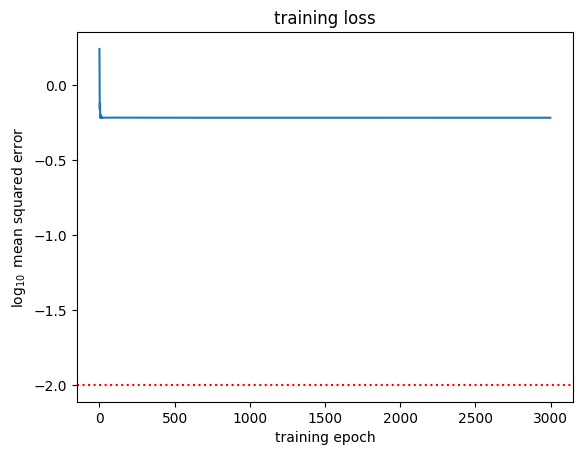

In [9]:
plt.plot(np.log10(history.history["loss"])); # one mse value per epoch
plt.title("training loss")
plt.xlabel("training epoch")
plt.ylabel(r"$\log_{10}$ mean squared error");
plt.axhline(y = np.log10(sigma**2), color = "red", linestyle = ":");

Observe that with our choice for the measurement noise the theoretical optimum for the mean squared error *on new data* is $10^{-2}$ (red dotted line).
### Use the model for predictions

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


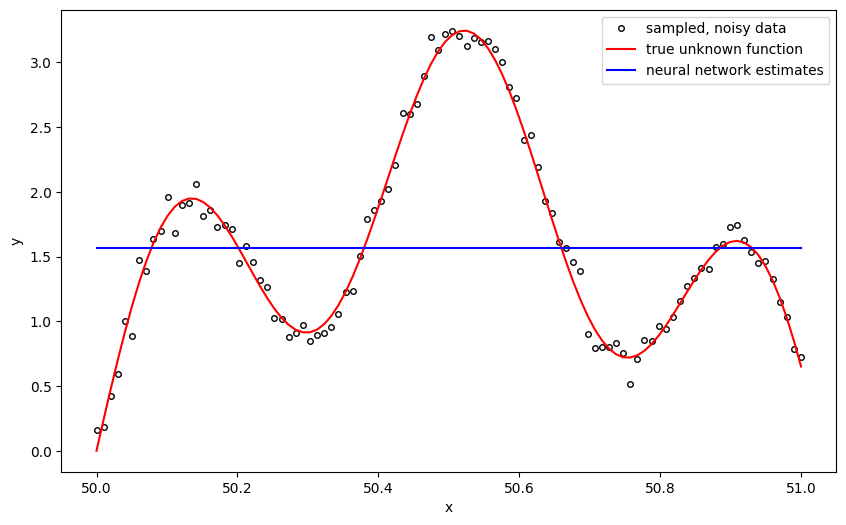

In [10]:
x_input = x.reshape((-1, 1)) # make x a matrix (with 1 column) as expected by predict
y_pred = model.predict(x_input)

ax = plot_curve()
ax.plot(x, y_pred, 'b', label = "neural network estimates") # (b)lue
ax.legend();